# Stellar-Age BNN (RGB): load → select → normalize → train → calibrate

End-to-end pipeline training on the **all-missions merged catalog with Willett
ages** (`merged_with_ages_raw.parquet`) — the same source dataset as the Cannon
notebook (`AnniesLasso/notebooks/train_rgb_wilett_all_missions.ipynb`). All
selection and normalization happens here, just before training; no pre-baked
BNN CSV to regenerate when the upstream catalog changes.

1. **Load & select** fully inlined in section 3: the Cannon notebook's cuts
   (finite `age_L`, ASPCAP sentinels, `RelAge_L`, young-α-rich impostors), RGB
   state from seismic `EvoState` (optionally extended to K2/TESS via
   `SELECTION_FILE`), Astra `raw_*` columns mapped to the BNN convention. Then
   dedup, drop unphysical ages, and a **stratified** train/val/test split on
   logAge bins (persisted to `split_assignments.csv`).
2. **Normalize** — derive `[C/N]` and Salaris `[M/H]`, standardize with
   **train-only** statistics (no leakage). Includes a young-tail label audit.
3. **Train** the robust BNN with input-uncertainty propagation and
   minibatch-correct ELBO scaling. Hyperparameters are the val-selected winner
   of the 48-config PBS sweep (`sweep_rgb_bnn.py`, result_008).
4. **Calibrate** on the val split (robust σ factor + inverse-calibration
   de-shrinkage), then **evaluate once** on the held-out test split, with
   ridge/kNN/GBT baselines and σ-informativeness diagnostics.
5. **Verify & record** — round-trip the saved inference bundle through the exact
   reload path `predict_bulge_ages.py` uses, and write a `run_manifest.json`.

Designed to run on Gadi (or anywhere the repo + dataset live).

## 1. Setup

In [71]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# The repo holding prepare_dataset.py / train_bnn.py is located in the next cell.

In [72]:

CANDIDATES = [
    '~/scr_mk27/bingo-modern',
    '~/code/bingo-modern',
    '.',
]
repo = next((p for p in map(os.path.expanduser, CANDIDATES)
             if os.path.isfile(os.path.join(p, 'train_bnn.py'))), None)
if repo is None:
    raise FileNotFoundError('Could not find train_bnn.py. Add its dir to CANDIDATES.')
repo = os.path.abspath(repo)
os.chdir(repo)
sys.path.insert(0, repo)
print('repo:', repo)

from train_bnn import (
    set_seed,
    BayesianNeuralNetwork,
    train_smooth_bnn,
    get_targeted_posterior_samples,
    analyze_targeted_results,
    device,
)
print(f'Using device: {device}')

repo: /home/100/mj8805/scr_mk27/bingo-modern
Using device: cuda


## 2. Configuration

In [73]:
# All-missions merged catalog with Willett ages -- the SAME source dataset the
# Cannon notebook (AnniesLasso/notebooks/train_rgb_wilett_all_missions.ipynb)
# trains from. Selection + normalization happen in THIS notebook, just before
# training, so there is no separate dataset-preparation step to keep in sync.
DATASET = '~/scr_mk27/bulge-ages-and-orbits/data/merged_with_ages_raw.parquet'

# RGB selection persisted by the Cannon notebook (seismic + spectra-classifier
# accepted, p(RGB) > 0.9): brings in the K2/TESS stars that carry no seismic
# EvoState, roughly DOUBLING the sample (2026-07-27 run: 3434 seismic + 4335
# classified = 7769 RGB). Re-run the Cannon notebook's persist cell after any
# catalog re-export so this file stays in sync with the merged parquet.
SELECTION_FILE = os.path.expanduser(
    '~/scr_mk27/bulge-ages-and-orbits/data/rgb_selection_all_missions.parquet')
if not os.path.exists(SELECTION_FILE):
    print(f'NOTE: {SELECTION_FILE} not found -> falling back to seismic-only '
          'RGB selection (Kepler EvoState==1). Run the Cannon notebook cell '
          'that persists the selection to include K2/TESS.')
    SELECTION_FILE = None

OUTPUT_DIR = Path('./BNN_targeted_output_RGB')
OUTPUT_DIR.mkdir(exist_ok=True)

In [74]:
# Hyperparameters promoted from the 48-config PBS sweep (sweep_rgb_bnn.py,
# result_008: best val ELBO 503.9, val corr 0.802, RMS 0.184, slope 0.868).
# Selected on VAL only; this notebook performs the single test evaluation.
TEST_FRAC = 0.20         # held-out fraction, touched exactly once (section 7)
VAL_FRAC = 0.15          # tuning + uncertainty-calibration split (never trained on)
SEED = 42
NUM_ITERATIONS = 20000
BATCH_SIZE = 32          # sweep verdict: 32 over 128
HIDDEN_DIM = 32          # sweep verdict: 32 beat 64 and 128 on val ELBO
INITIAL_LR = 0.0025      # sweep verdict: 0.0025 over 0.001
LR_DECAY_PER_EPOCH = 0.995  # ~0.5x LR over ~140 epochs; set 1.0 for constant LR
WEIGHT_CLIP = 10.0       # max inverse-frequency weight ratio; sweep verdict: 10 over 30.
                         # Review the label audit (section 4) before raising further:
                         # upweighting the tail also upweights any mislabeled star in it.

# Label-precision cut, applied in section 3 before the split. The Willett
# 16/84 percentiles give per-star age precision; K2 (~80 d) and TESS (~27 d)
# time series yield far less precise seismic masses than 4-yr Kepler, and the
# 2026-07-28 all-missions run showed 8% unphysical (>13.8 Gyr) ages plus a
# noise-dominated old tail. Check the by-mission histogram in section 4
# before tuning the threshold; None disables the cut.
MAX_LOGAGE_ERR = 0.3     # dex (~factor-2 age precision)

# Prior on the GLOBAL intrinsic scatter (dex). Sweep verdict: on the Willett
# sample the original loose prior (0.1, 0.3) beat the tightened (0.05, 0.2)
# variant everything-else-equal; the winning run fit ~0.23 dex of genuine
# label scatter, so squeezing the global term only pushed misfit elsewhere.
INTRINSIC_PRIOR_SCATTER = 0.1
INTRINSIC_PRIOR_LOGSTD = 0.3

# Young-tail audit thresholds (section 4). The load step already drops the
# Cannon notebook's "young alpha-rich impostors" (age < 4 Gyr, [Mg/Fe] > 0.15,
# [C/N] > -0.2); the audit shows what survives that cut in the young tail.
YOUNG_LOGAGE = 0.1       # "young" threshold: logAge < 0.1 (< ~1.3 Gyr)
ALPHA_RICH_MGFE = 0.15   # [Mg/Fe] above this counts as alpha-rich

# Early stopping on the validation ELBO. Val is already held out for calibration
# (section 7); monitoring it during training lets us stop once it stops improving
# and rewind to the best checkpoint, so NUM_ITERATIONS becomes a ceiling rather
# than the exact run length. The sweep winner's best epoch was 259 -- if the
# restored best epoch printed in section 6 lands near the epoch ceiling, raise
# NUM_ITERATIONS and re-run.
EARLY_STOPPING = True
ES_PATIENCE = 8          # stop after this many consecutive evals with no improvement
ES_MIN_DELTA = 0.0       # min val-ELBO (nat) improvement that counts as progress
ES_EVAL_EVERY = 5        # evaluate the val ELBO every N epochs


## 3. Dataset preparation — fully in-notebook

Everything from the raw merged parquet to normalized tensors is defined and run
**in this notebook**: constants, loading/selection, label cleaning, engineered
features, normalization, and age weights. Edit the cells below and re-run — no
module reloads, no pre-baked files.

The selection mirrors the Cannon notebook (`train_rgb_wilett_all_missions.ipynb`):
finite Willett age, ASPCAP sentinels dropped, `RelAge_L`-unreliable ages dropped,
young-α-rich impostors dropped, RGB state from seismic `EvoState` optionally
extended to K2/TESS via the persisted classifier selection (`SELECTION_FILE`),
plus the label-precision cut (`MAX_LOGAGE_ERR`).

Two of these functions have twins in `prepare_dataset.py` that other code still
uses — `predict_bulge_ages.py` applies `derive_features`/`apply_norm` at
inference, and `sweep_rgb_bnn.py` runs the whole chain from the module. The
drift-check cell below fails loudly if the notebook and module versions diverge.

The split is **stratified on logAge quantile bins**; cleaning runs before the
split so the strata are exact; dedup keeps the highest-SNR row per star; the
realized membership is persisted to `split_assignments.csv`. Val is used for
tuning and calibration; **test is touched exactly once**, in section 7.

In [75]:
# --- Dataset-preparation constants & functions (self-contained) -------------
# The notebook is the source of truth; prepare_dataset.py keeps synced twins
# for the scripts (see the drift check below).

ID_COL = "APOGEE_ID"
BASE_FEATURES = ["LOGG", "TEFF", "MG_FE", "FE_H", "C_FE", "N_FE"]
TARGET = "logAge"
TARGET_ERR = "logAgeErr"
UNPHYSICAL_AGE_GYR = 13.8   # older than the Universe -> measurement failure
N_AGE_BINS = 12             # logAge bins for the inverse-frequency weights

# Features the model sees: base columns + engineered [C/N] and Salaris [M/H].
FEATURES = BASE_FEATURES + ['C_N', 'M_H']
FEATURE_COLS = [f'{f}_NORM' for f in FEATURES]
ERROR_COLS = [f'{f}_ERR_NORM' for f in FEATURES]


def _first_col(df, candidates, what):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of the candidate columns for {what} found: {candidates}. "
                   f"Available: {sorted(df.columns.tolist())}")


def load_willett_merged(path, target_state="rgb", impostor_cut=True,
                        selection_file=None):
    """Load the all-missions merged catalog and return the BNN column
    convention (BASE_FEATURES + errors, logAge/logAgeErr/age, APOGEE_ID, SNR,
    source), ready for clean_labels(). Selection mirrors the Cannon notebook;
    spectra columns are never read."""
    import pyarrow.parquet as pq
    spectra_cols = {"wavelength", "flux", "ivar"}
    names = pq.ParquetFile(path).schema_arrow.names
    df = pd.read_parquet(path, columns=[c for c in names if c not in spectra_cols])
    n0 = len(df)

    df = df[np.isfinite(df["age_L"])]

    # Abundance ratios from the Astra raw_*_h convention (X/Fe = X/H - Fe/H).
    for out, xh in [("mg_fe", "raw_mg_h"), ("c_fe", "raw_c_h"), ("n_fe", "raw_n_h")]:
        if out not in df.columns:
            df[out] = df[xh] - df["raw_fe_h"]
    if "c_n" not in df.columns:
        df["c_n"] = df["raw_c_h"] - df["raw_n_h"]

    sentinel_cols = [c for c in ("raw_teff", "raw_logg", "raw_fe_h", "raw_mg_h",
                                 "raw_c_h", "raw_n_h") if c in df.columns]
    sentinel = (df[sentinel_cols] < -100).any(axis=1)
    unreliable = ~df["RelAge_L"].astype(bool)
    impostor = ((df["age_L"] < 4) & (df["mg_fe"] > 0.15) & (df["c_n"] > -0.2)
                if impostor_cut else pd.Series(False, index=df.index))
    drop = sentinel | unreliable | impostor
    print(f"[merged catalog] {n0} rows -> {len(df)} with finite age_L; dropping "
          f"sentinel={int(sentinel.sum())}, RelAge_L=False={int(unreliable.sum())}, "
          f"impostors={int(impostor.sum())} (overlapping) -> {int((~drop).sum())} remain")
    df = df[~drop].reset_index(drop=True)

    id_col = _first_col(df, ["APOGEE_ID", "apogee_id", "sdss_id", "GAIADR3_ID"], "star ID")
    state_code = {"rgb": 1, "rc": 2}[target_state]
    if selection_file is not None:
        sel = (pd.read_parquet(selection_file) if str(selection_file).endswith(".parquet")
               else pd.read_csv(selection_file))
        sel_id = _first_col(sel, [id_col, "APOGEE_ID", "sdss_id"], "selection-file ID")
        keep_ids = set(sel.loc[sel["is_rgb"].astype(bool), sel_id])
        keep = df[id_col].isin(keep_ids)
        print(f"[state] selection file {selection_file}: {int(keep.sum())} of "
              f"{len(df)} rows kept")
    else:
        evo = pd.to_numeric(df.get("EvoState"), errors="coerce").fillna(0).astype(int)
        keep = evo == state_code
        n_missing = int((evo == 0).sum())
        print(f"[state] seismic EvoState=={state_code} only: {int(keep.sum())} of "
              f"{len(df)} rows kept ({n_missing} rows have no seismic state -- "
              "mostly K2/TESS; pass selection_file to include their classified subset)")
    if "source" in df.columns:
        print(df.loc[keep, "source"].value_counts().to_string())
    df = df[keep].reset_index(drop=True)

    out = pd.DataFrame()
    out[ID_COL] = df[id_col].astype(str)
    snr = next((c for c in ("snr", "SNR", "snr_x", "raw_snr") if c in df.columns), None)
    out["SNR"] = df[snr] if snr else 1.0
    # Mission provenance: never a model feature, only for diagnostics.
    out["source"] = df["source"].values if "source" in df.columns else "unknown"
    out["TEFF"] = df["raw_teff"]
    out["TEFF_ERR"] = df[_first_col(df, ["raw_e_teff", "e_teff"], "Teff error")]
    out["LOGG"] = df["raw_logg"]
    out["LOGG_ERR"] = df[_first_col(df, ["raw_e_logg", "e_logg"], "logg error")]
    out["FE_H"] = df["raw_fe_h"]
    fe_err = df[_first_col(df, ["raw_e_fe_h", "e_fe_h"], "Fe/H error")]
    out["FE_H_ERR"] = fe_err
    for feat, xh, exh in [("MG_FE", "raw_mg_h", ["raw_e_mg_h", "e_mg_fe"]),
                          ("C_FE", "raw_c_h", ["raw_e_c_h", "e_c_fe"]),
                          ("N_FE", "raw_n_h", ["raw_e_n_h", "e_n_fe"])]:
        out[feat] = df[xh] - df["raw_fe_h"]
        ecol = _first_col(df, exh, f"{feat} error")
        # raw_e_*_h errors combine with Fe/H in quadrature for the ratio;
        # e_*_fe columns are already ratio errors.
        out[f"{feat}_ERR"] = (np.sqrt(df[ecol] ** 2 + fe_err ** 2)
                              if ecol.startswith("raw_e_") else df[ecol])

    out["age"] = df["age_L"]
    out[TARGET] = np.log10(df["age_L"])
    if "log_age_L_err" in df.columns:
        out[TARGET_ERR] = df["log_age_L_err"]
    elif any(c in df.columns for c in ("e_age_L", "age_L_err")):
        e = df[_first_col(df, ["e_age_L", "age_L_err"], "age error")]
        out[TARGET_ERR] = e / (df["age_L"] * np.log(10.0))
    elif any(c in df.columns for c in ("age_16_L", "age_L_16")):
        lo = df[_first_col(df, ["age_16_L", "age_L_16"], "age 16th pct")]
        hi = df[_first_col(df, ["age_84_L", "age_L_84"], "age 84th pct")]
        out[TARGET_ERR] = (np.log10(hi) - np.log10(lo)) / 2.0
    else:
        age_like = [c for c in df.columns if "age" in c.lower()]
        raise KeyError("No Willett age-uncertainty column found. Age-related "
                       f"columns available: {age_like}")
    return out


def clean_labels(df, name):
    """Drop NaNs, unphysical (> UNPHYSICAL_AGE_GYR) ages, and non-positive errors."""
    n0 = len(df)
    report = {}
    need = [ID_COL, TARGET, TARGET_ERR, "age"] + \
           BASE_FEATURES + [f"{f}_ERR" for f in BASE_FEATURES]
    missing = [c for c in need if c not in df.columns]
    if missing:
        raise KeyError(f"[{name}] missing required columns: {missing}")

    cols = BASE_FEATURES + [f"{f}_ERR" for f in BASE_FEATURES] + [TARGET, TARGET_ERR]
    df = df.replace([np.inf, -np.inf], np.nan)
    before = len(df)
    df = df.dropna(subset=cols)
    report["dropped_nan"] = before - len(df)

    saturated = df["age"] > UNPHYSICAL_AGE_GYR
    report["dropped_unphysical_age"] = int(saturated.sum())
    df = df[~saturated]

    before = len(df)
    df = df[(df[TARGET_ERR] > 0)]
    for f in BASE_FEATURES:
        df = df[df[f"{f}_ERR"] > 0]
    report["dropped_bad_errors"] = before - len(df)

    print(f"[{name}] cleaning: {n0} -> {len(df)} rows  {report}")
    return df.reset_index(drop=True), report


def derive_features(df):
    """Add [C/N] and Salaris-corrected [M/H], each with propagated errors."""
    df = df.copy()
    df["C_N"] = df["C_FE"] - df["N_FE"]
    df["C_N_ERR"] = np.sqrt(df["C_FE_ERR"] ** 2 + df["N_FE_ERR"] ** 2)
    # Salaris et al. (1993) alpha-corrected global metallicity, [Mg/Fe] as the
    # alpha proxy: [M/H] = [Fe/H] + log10(0.638 * 10^[a/Fe] + 0.362).
    alpha_term = 0.638 * 10.0 ** df["MG_FE"]
    df["M_H"] = df["FE_H"] + np.log10(alpha_term + 0.362)
    dmg = alpha_term / (alpha_term + 0.362)
    df["M_H_ERR"] = np.sqrt(df["FE_H_ERR"] ** 2 + (dmg * df["MG_FE_ERR"]) ** 2)
    return df


def fit_norm_stats(train_df, features):
    """Standardization stats from TRAIN ONLY: x_norm=(x-mu)/sigma, xerr_norm=xerr/sigma."""
    stats = {}
    for f in features:
        mu = float(train_df[f].mean())
        sigma = float(train_df[f].std(ddof=0))
        if sigma == 0 or not np.isfinite(sigma):
            sigma = 1.0
        stats[f] = {"mean": mu, "std": sigma}
    return stats


def apply_norm(df, features, stats):
    df = df.copy()
    for f in features:
        mu, sigma = stats[f]["mean"], stats[f]["std"]
        df[f"{f}_NORM"] = (df[f] - mu) / sigma
        df[f"{f}_ERR_NORM"] = df[f"{f}_ERR"] / sigma
    return df


def add_sample_weights(df, n_bins, clip, min_bin_count=5):
    """Inverse-frequency weights per logAge bin -> flat effective age distribution.

    ``min_bin_count`` floors the occupancy used for the inverse frequency, so a
    bin holding one or two (possibly mislabeled) stars cannot hand them the
    weight of a full bin; the clip is enforced AFTER the mean-1 normalization.
    """
    df = df.copy()
    lo, hi = df[TARGET].min(), df[TARGET].max()
    edges = np.linspace(lo, hi, n_bins + 1)
    idx = np.clip(np.digitize(df[TARGET].values, edges[1:-1]), 0, n_bins - 1)
    counts = np.bincount(idx, minlength=n_bins).astype(float)
    counts[counts == 0] = np.nan
    eff = np.maximum(counts, float(min_bin_count))
    inv = np.nanmean(counts) / eff
    inv = np.clip(np.nan_to_num(inv, nan=clip), 1.0 / clip, clip)
    w = inv[idx]
    w = w / w.mean()
    w = np.clip(w, 1.0 / clip, clip)
    df["train_weight"] = w
    return df, edges, counts


def text_hist(values, edges, label):
    counts, _ = np.histogram(values, bins=edges)
    peak = max(counts.max(), 1)
    print(f"\n  {label} (logAge histogram, n={len(values)}):")
    for i in range(len(counts)):
        bar = "#" * int(40 * counts[i] / peak)
        print(f"    [{edges[i]:+.2f},{edges[i+1]:+.2f})  {counts[i]:4d} {bar}")


def validate(train_df, test_df, features, edges):
    print("\n" + "=" * 60)
    print("VALIDATION REPORT")
    print("=" * 60)
    text_hist(train_df[TARGET].values, edges, "TRAIN")
    text_hist(test_df[TARGET].values, edges, "TEST")
    counts, _ = np.histogram(train_df[TARGET].values, bins=edges,
                             weights=train_df["train_weight"].values)
    print("\n  TRAIN effective balance after weighting (should be ~flat):")
    peak = max(counts.max(), 1e-9)
    for i in range(len(counts)):
        bar = "#" * int(40 * counts[i] / peak)
        print(f"    [{edges[i]:+.2f},{edges[i+1]:+.2f})  {counts[i]:7.1f} {bar}")
    print(f"\n  Label noise (logAgeErr): mean={train_df[TARGET_ERR].mean():.3f} "
          f"median={train_df[TARGET_ERR].median():.3f} dex")
    const = train_df[TARGET_ERR].nunique() == 1
    print(f"  logAgeErr constant fill value? {'YES - SUSPECT' if const else 'no'}")
    overlap = set(train_df[ID_COL]) & set(test_df[ID_COL])
    print(f"\n  Train/test {ID_COL} overlap: {len(overlap)} "
          f"{'<-- LEAKAGE, remove these' if overlap else '(clean)'}")
    print(f"\n  Features used ({len(features)}): {features}")
    print("  Any NaN remaining in NORM features? "
          f"{train_df[[f + '_NORM' for f in features]].isna().any().any()}")


FEATURES

['LOGG', 'TEFF', 'MG_FE', 'FE_H', 'C_FE', 'N_FE', 'C_N', 'M_H']

In [76]:
# Drift check: predict_bulge_ages.py applies derive_features/apply_norm from
# prepare_dataset.py at inference, and sweep_rgb_bnn.py runs the module's full
# prep chain -- if the notebook versions above diverge from the module, bulge
# inference would silently apply a DIFFERENT transform than training. Fail here.
import prepare_dataset as _prep_mod

_probe = pd.DataFrame({
    'FE_H': [-0.31, 0.12], 'FE_H_ERR': [0.010, 0.021],
    'MG_FE': [0.21, -0.05], 'MG_FE_ERR': [0.012, 0.009],
    'C_FE': [-0.11, 0.05], 'C_FE_ERR': [0.011, 0.013],
    'N_FE': [0.22, 0.10], 'N_FE_ERR': [0.010, 0.012],
})
_nb = derive_features(_probe)
_md = _prep_mod.derive_features(_probe)
assert list(_nb.columns) == list(_md.columns) and np.allclose(_nb.values, _md.values), (
    'derive_features drifted from prepare_dataset.py -- sync them before trusting '
    'bulge inference.')
_cols = ['FE_H', 'C_N', 'M_H']
_stats = fit_norm_stats(_nb, _cols)
assert np.allclose(apply_norm(_nb, _cols, _stats).filter(like='_NORM').values,
                   _prep_mod.apply_norm(_nb, _cols, _stats).filter(like='_NORM').values), (
    'apply_norm drifted from prepare_dataset.py -- sync them.')
print('prepare_dataset.py twins are consistent (derive_features, apply_norm).')

prepare_dataset.py twins are consistent (derive_features, apply_norm).


In [77]:
# Load + select from the merged all-missions catalog (Cannon-notebook cuts:
# finite age_L, sentinels, RelAge_L, impostors, RGB state). Returns the BNN
# column convention: BASE_FEATURES + errors, logAge/logAgeErr/age, APOGEE_ID, SNR.
df = load_willett_merged(os.path.expanduser(DATASET),
                              target_state='rgb',
                              selection_file=SELECTION_FILE)
print(f'Selected {len(df)} RGB stars, {df.shape[1]} columns')

# Safety net: keep the highest-SNR row per star.
before = len(df)
df = (df.sort_values('SNR', ascending=False)
        .drop_duplicates(ID_COL, keep='first')
        .reset_index(drop=True))
print(f'Deduplicated by {ID_COL}: {before} -> {len(df)} stars')

# Clean labels BEFORE splitting (pure row filter, so no leakage): the strata below
# are then computed on exactly the surviving stars and the fractions are exact.
df, clean_rep = clean_labels(df, 'full catalog')
df = df.reset_index(drop=True)

# Snapshot pre-cut label errors for the by-mission histogram in section 4.
label_err_precut = df[['source', TARGET_ERR]].copy()

# Label-precision cut: stars whose Willett age is too imprecise teach the
# model noise (bad K2/TESS seismology preferentially lands here).
if MAX_LOGAGE_ERR is not None:
    n_precut = len(df)
    df = df[df[TARGET_ERR] <= MAX_LOGAGE_ERR].reset_index(drop=True)
    print(f'Label-precision cut (logAgeErr <= {MAX_LOGAGE_ERR} dex): '
          f'{n_precut} -> {len(df)} stars')

# Stratified train/val/test split on logAge quantile bins (fixed seed).
rng = np.random.default_rng(SEED)
strata = pd.qcut(df[TARGET], q=10, labels=False, duplicates='drop')
train_idx, val_idx, test_idx = [], [], []
for b in np.unique(strata):
    members = rng.permutation(np.flatnonzero(strata == b))
    n_test = int(round(TEST_FRAC * len(members)))
    n_val = int(round(VAL_FRAC * len(members)))
    test_idx.extend(members[:n_test])
    val_idx.extend(members[n_test:n_test + n_val])
    train_idx.extend(members[n_test + n_val:])
train = df.iloc[sorted(train_idx)].reset_index(drop=True)
val = df.iloc[sorted(val_idx)].reset_index(drop=True)
test = df.iloc[sorted(test_idx)].reset_index(drop=True)
print(f'Train: {len(train)}  |  Val: {len(val)}  |  Test: {len(test)}')

# Persist the realized split: the seed alone does not pin it (it also depends on
# the exact catalog), so downstream scripts audit membership from this file.
pd.concat([s[[ID_COL]].assign(split=name)
           for name, s in [('train', train), ('val', val), ('test', test)]]
          ).to_csv(OUTPUT_DIR / 'split_assignments.csv', index=False)
print(f"Split membership saved to {OUTPUT_DIR / 'split_assignments.csv'}")
train.head()

[merged catalog] 23708 rows -> 20808 with finite age_L; dropping sentinel=35, RelAge_L=False=4642, impostors=236 (overlapping) -> 15990 remain
[state] selection file /home/100/mj8805/scr_mk27/bulge-ages-and-orbits/data/rgb_selection_all_missions.parquet: 7783 of 15990 rows kept
source
K2        3860
Kepler    3483
TESS       440
Selected 7783 RGB stars, 18 columns
Deduplicated by APOGEE_ID: 7783 -> 7513 stars
[full catalog] cleaning: 7513 -> 6632 rows  {'dropped_nan': 282, 'dropped_unphysical_age': 599, 'dropped_bad_errors': 0}
Label-precision cut (logAgeErr <= 0.3 dex): 6632 -> 6475 stars
Train: 4210  |  Val: 970  |  Test: 1295
Split membership saved to BNN_targeted_output_RGB/split_assignments.csv


,APOGEE_ID,SNR,source,TEFF,TEFF_ERR,LOGG,LOGG_ERR,FE_H,FE_H_ERR,MG_FE,MG_FE_ERR,C_FE,C_FE_ERR,N_FE,N_FE_ERR,age,logAge,logAgeErr
0,2M04051699+1340131,1007.762878,K2,4669.827148,0.889,2.567,0.002,-0.344,0.001,0.024,0.002449,-0.077,0.002449,0.173,0.002449,3.817026,0.581725,0.070796
1,2M03520104+2236103,999.598572,K2,4642.055176,0.802,2.552,0.002,-0.327,0.001,0.044,0.001732,-0.054,0.002449,0.200,0.002449,5.149073,0.711729,0.053321
2,2M05252181-5739002,996.492065,TESS,4599.305176,0.697,2.764,0.001,-0.161,0.001,0.064,0.001732,0.015,0.001732,0.156,0.002449,7.044464,0.847848,0.058091
3,2M08545739+1201313,974.760681,K2,4765.499023,0.946,2.931,0.002,-0.186,0.001,0.051,0.001732,-0.048,0.002449,0.188,0.002449,7.899614,0.897606,0.116707
4,2M19412463+4003196,962.878235,Kepler,4657.907227,0.848,2.584,0.002,-0.313,0.001,0.052,0.001732,-0.031,0.002449,0.185,0.002449,5.388563,0.731473,0.045611


## 4. Normalize

Derive `[C/N]` (with propagated error) and standardize with **train-only** statistics.
Val and test are transformed with the train statistics; the inverse-frequency age
weights are computed on train only. (Label cleaning already happened in section 3,
before the split.)

In [78]:
# Dedup-before-split makes overlap impossible; verify rather than assume.
ids = {name: set(s[ID_COL]) for name, s in [('train', train), ('val', val), ('test', test)]}
for a, b in [('train', 'val'), ('train', 'test'), ('val', 'test')]:
    overlap = ids[a] & ids[b]
    assert not overlap, f'{len(overlap)} stars appear in both {a} and {b}'

# Engineer [C/N] (+ propagated error)
train = derive_features(train)
val = derive_features(val)
test = derive_features(test)

# Fit normalization on TRAIN ONLY, then apply to all splits
stats = fit_norm_stats(train, FEATURES)
train = apply_norm(train, FEATURES, stats)
val = apply_norm(val, FEATURES, stats)
test = apply_norm(test, FEATURES, stats)

# Inverse-frequency sample weights to fight age imbalance (train only)
train, edges, _ = add_sample_weights(train, N_AGE_BINS, WEIGHT_CLIP)

print(f'\nTrain: {len(train)} | Val: {len(val)} | Test: {len(test)} stars')
train[FEATURE_COLS].describe()


Train: 4210 | Val: 970 | Test: 1295 stars


,LOGG_NORM,TEFF_NORM,MG_FE_NORM,FE_H_NORM,C_FE_NORM,N_FE_NORM,C_N_NORM,M_H_NORM
count,4.210000e+03,4210.000000,4.210000e+03,4.210000e+03,4.210000e+03,4.210000e+03,4.210000e+03,4.210000e+03
mean,-7.720005e-07,0.000003,3.624416e-08,-1.449766e-08,7.248831e-09,2.537091e-08,8.698597e-08,5.436623e-09
std,1.000119e+00,1.000120,1.000118e+00,1.000118e+00,1.000121e+00,1.000119e+00,1.000117e+00,1.000119e+00
min,-3.372188e+00,-3.064578,-3.289034e+00,-7.774829e+00,-1.724854e+01,-7.008478e+00,-5.591483e+00,-8.405630e+00
25%,-7.164947e-01,-0.720349,-7.299339e-01,-6.585021e-01,-6.481713e-01,-5.703204e-01,-6.602993e-01,-6.259218e-01
50%,-7.769296e-02,-0.084883,-3.407172e-01,5.697720e-02,-2.217965e-02,5.979698e-02,-5.759904e-02,6.939000e-03
75%,8.015563e-01,0.691433,4.936662e-01,7.301432e-01,7.313284e-01,5.894609e-01,6.729466e-01,6.885618e-01
max,3.238334e+00,5.086923,3.016277e+00,2.184182e+00,1.050375e+01,6.452293e+00,9.561254e+00,2.705604e+00


In [79]:
validate(train, test, FEATURES, edges)


VALIDATION REPORT

  TRAIN (logAge histogram, n=4210):
    [-0.88,-0.72)     1 
    [-0.72,-0.55)     1 
    [-0.55,-0.38)     8 
    [-0.38,-0.21)    12 
    [-0.21,-0.04)    22 
    [-0.04,+0.13)    40 #
    [+0.13,+0.30)    96 ##
    [+0.30,+0.47)   226 ######
    [+0.47,+0.63)   507 ###############
    [+0.63,+0.80)   834 ########################
    [+0.80,+0.97)  1348 ########################################
    [+0.97,+1.14)  1115 #################################

  TEST (logAge histogram, n=1295):
    [-0.88,-0.72)     0 
    [-0.72,-0.55)     1 
    [-0.55,-0.38)     1 
    [-0.38,-0.21)     0 
    [-0.21,-0.04)     5 
    [-0.04,+0.13)    11 #
    [+0.13,+0.30)    23 ##
    [+0.30,+0.47)    82 #######
    [+0.47,+0.63)   158 ##############
    [+0.63,+0.80)   252 #######################
    [+0.80,+0.97)   428 ########################################
    [+0.97,+1.14)   334 ###############################

  TRAIN effective balance after weighting (should be ~flat):
    [-0

### Young-tail label audit

A known failure mode for RGB age labels: **apparently-young α-rich stars** are
frequently mass-transfer/merger products — their current mass (which the age
derives from) is not their birth mass, so the "young" reference age is wrong,
while their [C/N] genuinely looks old.

The load step already drops the Cannon notebook's impostor definition (age < 4 Gyr,
[Mg/Fe] > 0.15, **and old-like [C/N] > −0.2**). This audit flags what *survives*
in the young tail: young α-rich stars whose [C/N] looks young (≤ −0.2). Those are
either genuinely young thick-disk-like stars or subtler contaminants — review the
flagged list before trusting (or upweighting) the young tail, and cross-check
their IDs against the worst-offender table in section 7.

Young (logAge < 0.1, < ~1.3 Gyr): 87 stars in train+val
  of which alpha-rich ([Mg/Fe] > 0.15): 3 (3%) <- survived the impostor cut; review before trusting the young tail


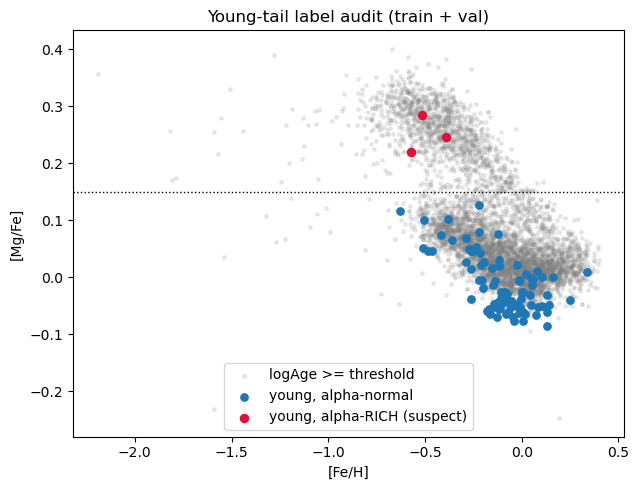


Flagged stars (review before believing -- or upweighting -- the young tail):
         APOGEE_ID    logAge      age   FE_H  MG_FE _split
2M16151925-2543127 -0.440464 0.362690 -0.574  0.220  train
2M16384278-2154129 -0.087118 0.818242 -0.393  0.247  train
2M00382370+0819102 -0.025916 0.942072 -0.514  0.285  train


In [80]:
# Diagnostic only: flags and counts, drops nothing. The hard impostor cut
# (young + alpha-rich + old-like [C/N]) already ran inside load_willett_merged;
# what shows up here survived it. Test is excluded so its labels stay untouched.
audit = pd.concat([train.assign(_split='train'), val.assign(_split='val')],
                  ignore_index=True)
young = audit[TARGET] < YOUNG_LOGAGE
arich = audit['MG_FE'] > ALPHA_RICH_MGFE
flagged = audit[young & arich]

print(f'Young (logAge < {YOUNG_LOGAGE}, < ~{10**YOUNG_LOGAGE:.1f} Gyr): '
      f'{int(young.sum())} stars in train+val')
print(f'  of which alpha-rich ([Mg/Fe] > {ALPHA_RICH_MGFE}): {len(flagged)} '
      f'({len(flagged) / max(int(young.sum()), 1):.0%}) <- survived the '
      'impostor cut; review before trusting the young tail')

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(audit.loc[~young, 'FE_H'], audit.loc[~young, 'MG_FE'],
           s=6, alpha=0.15, color='grey', label='logAge >= threshold')
ax.scatter(audit.loc[young & ~arich, 'FE_H'], audit.loc[young & ~arich, 'MG_FE'],
           s=28, color='tab:blue', label='young, alpha-normal')
ax.scatter(flagged['FE_H'], flagged['MG_FE'],
           s=34, color='crimson', label='young, alpha-RICH (suspect)')
ax.axhline(ALPHA_RICH_MGFE, color='k', ls=':', lw=1)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Mg/Fe]')
ax.set_title('Young-tail label audit (train + val)')
ax.legend()
plt.tight_layout()
plt.show()

if len(flagged):
    print('\nFlagged stars (review before believing -- or upweighting -- the young tail):')
    print(flagged[[ID_COL, TARGET, 'age', 'FE_H', 'MG_FE', '_split']]
          .sort_values(TARGET).to_string(index=False))

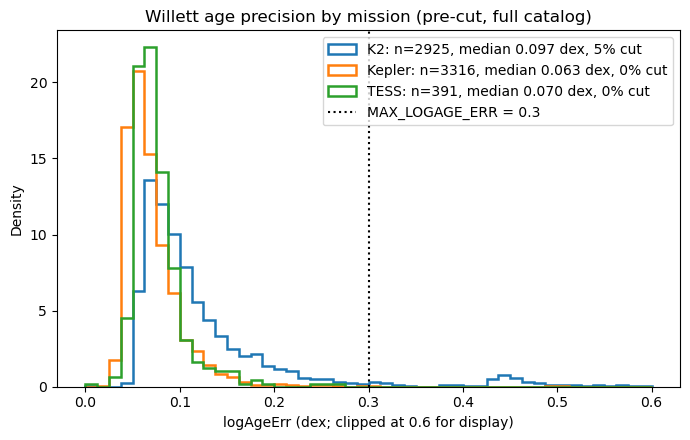

In [81]:
# Label quality by mission: K2 campaigns (~80 d) and TESS sectors (~27 d) give
# far less precise seismic masses than 4-yr Kepler. Distributions are PRE-cut
# (snapshotted in section 3) so the effect of MAX_LOGAGE_ERR is visible;
# tune the threshold against this plot.
fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.linspace(0, 0.6, 49)
thresh = MAX_LOGAGE_ERR if MAX_LOGAGE_ERR is not None else np.inf
for src, g in label_err_precut.groupby('source'):
    e = g[TARGET_ERR]
    ax.hist(e.clip(upper=0.6), bins=bins, histtype='step', lw=1.8, density=True,
            label=(f'{src}: n={len(g)}, median {e.median():.3f} dex, '
                   f'{(e > thresh).mean():.0%} cut'))
if MAX_LOGAGE_ERR is not None:
    ax.axvline(MAX_LOGAGE_ERR, color='k', ls=':', lw=1.5,
               label=f'MAX_LOGAGE_ERR = {MAX_LOGAGE_ERR}')
ax.set_xlabel('logAgeErr (dex; clipped at 0.6 for display)')
ax.set_ylabel('Density')
ax.set_title('Willett age precision by mission (pre-cut, full catalog)')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Build tensors

In [82]:
def to_arrays(d):
    X = d[FEATURE_COLS].values.astype(np.float32)
    X_err = d[ERROR_COLS].values.astype(np.float32)
    y = d[TARGET].values.astype(np.float32)
    y_err = d[TARGET_ERR].values.astype(np.float32)
    # Inverse-frequency age weights (mean 1). Val/test have no weights -> ones.
    w = (d['train_weight'].values if 'train_weight' in d.columns
         else np.ones(len(d))).astype(np.float32)
    return X, X_err, y, y_err, w


def to_tensor(a):
    return torch.as_tensor(a, dtype=torch.float32, device=device)


X_train, X_err_train, y_train, y_err_train, w_train = to_arrays(train)
X_val, X_err_val, y_val, y_err_val, _ = to_arrays(val)
X_test, X_err_test, y_test, y_err_test, _ = to_arrays(test)

print(f'Features: {X_train.shape[1]}  ({FEATURE_COLS})')
print(f'logAge range: [{y_train.min():.3f}, {y_train.max():.3f}]')
print(f'train_weight: mean={w_train.mean():.3f}, min={w_train.min():.3f}, max={w_train.max():.3f}')

X_train_t = to_tensor(X_train)
X_err_train_t = to_tensor(X_err_train)
y_train_t = to_tensor(y_train)
y_err_train_t = to_tensor(y_err_train)

# Validation tensors for early-stopping (monitored during training, section 6).
X_val_t = to_tensor(X_val)
X_err_val_t = to_tensor(X_err_val)
y_val_t = to_tensor(y_val)
y_err_val_t = to_tensor(y_err_val)

# Bare inverse-frequency weights (mean 1). The minibatch-correct ELBO scaling
# (likelihood x N/len(batch)) is applied inside train_smooth_bnn via
# minibatch_scale=True, using the actual batch length each step -- do NOT
# pre-multiply by N/BATCH_SIZE here.
w_train_t = to_tensor(w_train)

Features: 8  (['LOGG_NORM', 'TEFF_NORM', 'MG_FE_NORM', 'FE_H_NORM', 'C_FE_NORM', 'N_FE_NORM', 'C_N_NORM', 'M_H_NORM'])
logAge range: [-0.884, 1.140]
train_weight: mean=0.926, min=0.378, max=10.000


## 6. Train the network

In [83]:
set_seed(SEED)

y_mean = float(np.mean(y_train))
y_std = float(np.std(y_train))
print(f'Empirical logAge stats - mean: {y_mean:.3f}, std: {y_std:.3f}')

MODEL_KWARGS = dict(
    input_dim=X_train.shape[1],
    hidden_dim=HIDDEN_DIM,
    use_skip_connections=True,
    use_empirical_output_bias=True,  # mean-zero bias prior: less shrinkage to y_mean
    use_leaky_relu=True,
    y_mean=y_mean,
    y_std=y_std,
    # Global intrinsic-scatter prior, selected by the sweep (see section 2).
    intrinsic_scatter_prior=INTRINSIC_PRIOR_SCATTER,
    intrinsic_scatter_prior_logstd=INTRINSIC_PRIOR_LOGSTD,
)
model = BayesianNeuralNetwork(**MODEL_KWARGS)
model.to(device)

guide, losses = train_smooth_bnn(
    model,
    X_train_t, X_err_train_t,
    y_train_t, y_err_train_t,
    num_iterations=NUM_ITERATIONS,
    initial_lr=INITIAL_LR,
    lr_decay_per_epoch=LR_DECAY_PER_EPOCH,
    batch_size=BATCH_SIZE,
    seed=SEED,
    w_train=w_train_t,        # bare inverse-frequency age weights (mean 1)
    minibatch_scale=True,     # likelihood x N/len(batch), applied internally
    # Early stopping on the unweighted validation ELBO. NUM_ITERATIONS is now a
    # ceiling; training halts once val stops improving and the best checkpoint
    # is restored into the Pyro param store before we save/evaluate below.
    X_val=X_val_t, X_err_val=X_err_val_t,
    y_val=y_val_t, y_err_val=y_err_val_t,
    early_stopping=EARLY_STOPPING,
    patience=ES_PATIENCE,
    min_delta=ES_MIN_DELTA,
    eval_every=ES_EVAL_EVERY,
    restore_best=True,
)

Empirical logAge stats - mean: 0.798, std: 0.250

Training Smooth Bayesian Neural Network
Using random seed: 42
Parameter store cleared for clean training start
Training for 151 epochs with 132 batches per epoch...
Total iterations: 20000
Initial learning rate: 0.0025 (decay 0.995/epoch)
Batch size: 32 (covers 0.8% of data per batch)
Minibatch ELBO scaling: likelihood x N/len(batch) (~131.6)
Early stopping: monitor val ELBO every 5 epoch(s), patience 8, min_delta 0.0


Training:  66%|███████████████████████████████████████████████                        | 100/151 [10:22<05:17,  6.23s/it, loss=2414.01, smooth=3465.11, lr=0.00151, val=716.10, best_val=716.10]

Epoch 100/151: Loss = 2414.0129 ± 6227.8993, Smoothed = 3465.1127


Training:  92%|██████████████████████████████████████████████████████████████▌     | 139/151 [14:31<01:15,  6.27s/it, loss=18398.88, smooth=10170.68, lr=0.00124, val=1146.94, best_val=716.10]


Early stopping at epoch 140: no val-ELBO improvement for 8 evals (best 716.1018 @ epoch 100).
Restored best params from epoch 100 (val ELBO 716.1018).

Training complete!
Final loss: 18398.8801
Final smoothed loss: 10170.6784
Best smoothed loss: 3219.6354
Best val ELBO: 716.1018 @ epoch 100
Loss improvement: 21763.8891


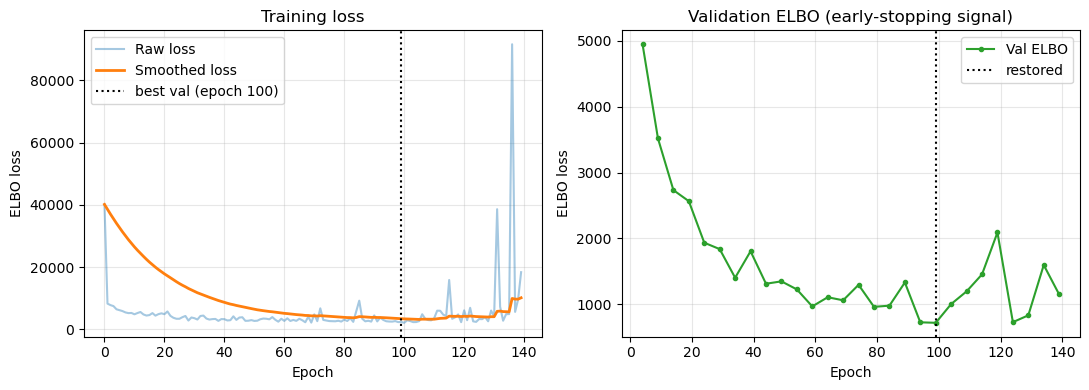

In [84]:
import pyro

# With early stopping the best-val checkpoint was already restored into the param
# store inside train_smooth_bnn, so this saves the best state, not the last epoch.
pyro.get_param_store().save(str(OUTPUT_DIR / 'targeted_bnn_params.pth'))

smoothed = []
for i, loss in enumerate(losses):
    smoothed.append(loss if i == 0 else 0.95 * smoothed[-1] + 0.05 * loss)

val_hist = getattr(model, 'val_losses_', [])
best_epoch = getattr(model, 'best_epoch_', -1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: training ELBO (raw + smoothed); dotted line = restored best-val epoch.
axes[0].plot(losses, alpha=0.4, label='Raw loss')
axes[0].plot(smoothed, lw=2, label='Smoothed loss')
if best_epoch >= 0:
    axes[0].axvline(best_epoch, color='k', ls=':', lw=1.5,
                    label=f'best val (epoch {best_epoch + 1})')
axes[0].set_title('Training loss')
axes[0].legend()

# Right: the early-stopping signal. Val ELBO falls, then flattens/turns up as the
# model starts overfitting; the dotted line marks where we rewound to. With early
# stopping off, fall back to the tail-zoom diagnostic instead.
if val_hist:
    ve, vl = zip(*val_hist)
    axes[1].plot(ve, vl, 'o-', color='tab:green', ms=3, label='Val ELBO')
    if best_epoch >= 0:
        axes[1].axvline(best_epoch, color='k', ls=':', lw=1.5, label='restored')
    axes[1].set_title('Validation ELBO (early-stopping signal)')
    axes[1].legend()
else:
    tail = max(len(losses) - 30, 0)
    axes[1].plot(range(tail, len(losses)), losses[tail:], alpha=0.4)
    axes[1].plot(range(tail, len(losses)), smoothed[tail:], lw=2)
    axes[1].set_title('Last 30 epochs')

for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('ELBO loss')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Calibrate on val, evaluate on test

Posterior predictions on the **val** split fit two corrections, both applied to test:

- **σ recalibration** — a single scalar for the predicted uncertainties (1.0 =
  already calibrated, < 1 = the raw uncertainties are inflated). The factor is the
  **robust** width of the val z-scores (1.4826·MAD, which equals the std for a
  Gaussian) rather than the plain std, so a handful of outlier stars cannot inflate
  it and de-calibrate everyone else; a large gap between the two estimates signals
  heavy tails rather than a wrong σ scale.
- **De-shrinkage via the inverse calibration fit** — fit `pred ≈ c·true + d` on val
  (σ-clipped) and invert: `pred' = (pred − d)/c`. The direction is deliberate:
  regressing `true` on `pred` is the MSE-optimal correction and *increases*
  shrinkage; the inverse fit is what makes E[pred'|true] track true, flattening
  the residual-vs-age trend at the cost of some extra scatter. It adds no
  information (rank order is unchanged) but removes the bias that matters for
  downstream old-vs-young comparisons. The debiased predictions get their own
  robust σ factor.

The **test** split is then evaluated once, reporting raw, calibrated, and debiased
coverage (targets: ~68% within 1σ, ~95% within 2σ). Each prediction is also flagged
if it falls outside the training logAge range — those stars are extrapolation
failures, not merely uncertain.

In [85]:
def predict_split(*, X, X_err, y_err, y):
    # Keyword-only on purpose: y_err and y are adjacent same-shape float arrays,
    # so a positional swap would run silently and corrupt every metric downstream.
    X_t = to_tensor(X)
    X_err_t = to_tensor(X_err)
    y_err_t = to_tensor(y_err)
    samples, mean_pred, model_unc, intrinsic = get_targeted_posterior_samples(
        model, guide, X_t, X_err_t, y_err_t, num_samples=5000
    )
    return analyze_targeted_results(samples, mean_pred, model_unc, intrinsic, y_err, y)


print('=== VAL (calibration split) ===')
summary_val = predict_split(X=X_val, X_err=X_err_val, y_err=y_err_val, y=y_val)

# Scalar recalibration: if the uncertainties were right, z = residual/sigma would
# have unit width on val. Applied factor = robust width (1.4826*MAD == std for a
# Gaussian) so outlier stars cannot inflate it; compare with the plain std -- a
# big gap means heavy tails, which a scalar rescaling cannot fix.
z_val = summary_val['normalized_residual']
calib_std = float(z_val.std())
calib = float(1.4826 * (z_val - z_val.median()).abs().median())
print(f'\nCalibration factor (val): {calib:.3f} robust (applied)  |  {calib_std:.3f} plain std')
if abs(calib_std - calib) > 0.1 * calib:
    print('  NOTE: std and robust width disagree by >10% -> heavy-tailed z '
          'distribution; check the per-age calibration plot below.')

# De-shrinkage via the INVERSE calibration fit on val. Direction matters:
# regressing true on pred is the MSE-optimal correction and *increases*
# shrinkage (tried; it made the residual-vs-age trend worse). To make
# E[pred'|true] track true, fit pred ~ c*true + d and invert. Sigma-clipped so
# a single catastrophic prediction cannot tilt the line.
p_v = summary_val['pred_median'].values
t_v = summary_val['true_age'].values
keep = np.ones(len(p_v), dtype=bool)
for _ in range(3):
    c_cal, d_cal = np.polyfit(t_v[keep], p_v[keep], 1)
    fit_resid = p_v - (c_cal * t_v + d_cal)
    scale = 1.4826 * np.median(np.abs(fit_resid[keep] - np.median(fit_resid[keep])))
    if scale == 0:
        break
    keep = np.abs(fit_resid) < 3 * scale
a_cal = 1.0 / c_cal        # expressed as pred' = a*pred + b, the form
b_cal = -d_cal / c_cal     # the inference bundle consumes
z_val_db = pd.Series((t_v - (a_cal * p_v + b_cal))
                     / summary_val['total_predictive_uncertainty'].values)
calib_db = float(1.4826 * (z_val_db - z_val_db.median()).abs().median())
print(f'Inverse-calibration de-shrinkage (val, kept {int(keep.sum())}/{len(keep)} '
      f'after clipping): pred\' = {a_cal:.3f} * pred {b_cal:+.3f}; '
      f'debiased sigma factor {calib_db:.3f}')

print('\n=== TEST (held out, evaluated once) ===')
summary = predict_split(X=X_test, X_err=X_err_test, y_err=y_err_test, y=y_test)
summary.insert(0, 'APOGEE_ID', test[ID_COL].values)   # traceability
summary.insert(1, 'source', test['source'].values)  # per-mission diagnostics
summary['calibrated_uncertainty'] = summary['total_predictive_uncertainty'] * calib
summary['calibrated_z'] = summary['residual'] / summary['calibrated_uncertainty']
summary['pred_debiased'] = a_cal * summary['pred_median'] + b_cal
summary['residual_debiased'] = summary['true_age'] - summary['pred_debiased']
summary['debiased_uncertainty'] = summary['total_predictive_uncertainty'] * calib_db
summary['debiased_z'] = summary['residual_debiased'] / summary['debiased_uncertainty']

# Extrapolation flag: a median prediction outside the training label range means
# the network left the region the data constrains -- treat those stars as broken,
# not merely uncertain (see the worst-offender table below).
train_lo, train_hi = float(y_train.min()), float(y_train.max())
summary['pred_outside_train_range'] = ((summary['pred_median'] < train_lo) |
                                       (summary['pred_median'] > train_hi))
n_out = int(summary['pred_outside_train_range'].sum())
if n_out:
    print(f'\nWARNING: {n_out} test prediction(s) outside the training logAge '
          f'range [{train_lo:.2f}, {train_hi:.2f}]')

print('\nTest coverage (targets: 68% within 1 sigma, 95% within 2):')
for name, z in [('raw       ', summary['normalized_residual']),
                ('calibrated', summary['calibrated_z']),
                ('debiased  ', summary['debiased_z'])]:
    print(f'  {name}  |z|<1: {(z.abs() < 1).mean():6.1%}   |z|<2: {(z.abs() < 2).mean():6.1%}')

summary.to_csv(OUTPUT_DIR / 'targeted_prediction_summary.csv', index=False)
summary.head()

=== VAL (calibration split) ===

Generating 5000 posterior samples from targeted model...
Combining uncertainty components...
Mean intrinsic scatter: 0.2399 ± 0.0089 dex
Mean model uncertainty: 0.0743 dex
Mean observational uncertainty: 0.0882 dex

HIGH AGE STAR PERFORMANCE (logAge > 1):
Number of high age stars: 199
High age MAE: 0.1524 dex
High age RMS: 0.1950 dex
High age correlation: 0.007
High age fraction within 1σ: 90.5%
High age prediction range: [0.5322, 1.6414]
High age prediction mean: 0.9941

TARGETED MODEL RESULTS:
Mean observational uncertainty: 0.0882 dex
Mean model uncertainty: 0.0743 dex
Intrinsic scatter: 0.2399 dex
Mean total uncertainty: 0.3716 dex

Overall Performance Metrics:
Mean Absolute Error: 0.1422 dex
RMS Error: 0.1963 dex
Correlation: 0.675
Fraction within 1σ: 93.7%
Fraction within 2σ: 99.7%

Calibration factor (val): 0.486 robust (applied)  |  0.530 plain std
Inverse-calibration de-shrinkage (val, kept 946/970 after clipping): pred' = 1.551 * pred -0.418; 

,APOGEE_ID,source,observational_uncertainty,model_uncertainty,intrinsic_scatter,total_predictive_uncertainty,pred_median,pred_mean_only,true_age,theoretical_total,residual,normalized_residual,calibrated_uncertainty,calibrated_z,pred_debiased,residual_debiased,debiased_uncertainty,debiased_z,pred_outside_train_range
0,2M03305441+1908236,K2,0.054242,0.073688,0.239931,0.286693,0.604892,0.602299,0.793764,0.256786,0.188873,0.658798,0.139239,1.356459,0.520277,0.273487,0.198393,1.378514,False
1,2M19394334+3929329,Kepler,0.059704,0.073662,0.239931,0.296481,0.744768,0.746506,0.659082,0.257987,-0.085685,-0.289008,0.143993,-0.595065,0.737295,-0.078212,0.205166,-0.381214,False
2,2M07153025-5902287,TESS,0.045667,0.073623,0.239931,0.286998,0.783096,0.779505,0.750563,0.255093,-0.032533,-0.113356,0.139388,-0.233400,0.796760,-0.046198,0.198604,-0.232612,False
3,2M19010645+4524187,Kepler,0.042735,0.073498,0.239931,0.293884,0.465527,0.471059,0.424882,0.254549,-0.040645,-0.138302,0.142732,-0.284763,0.304053,0.120829,0.203369,0.594139,False
4,2M05042388+2226360,K2,0.061552,0.073645,0.239931,0.415619,0.345799,0.340900,0.517074,0.258416,0.171275,0.412096,0.201856,0.848502,0.118295,0.398779,0.287611,1.386524,False


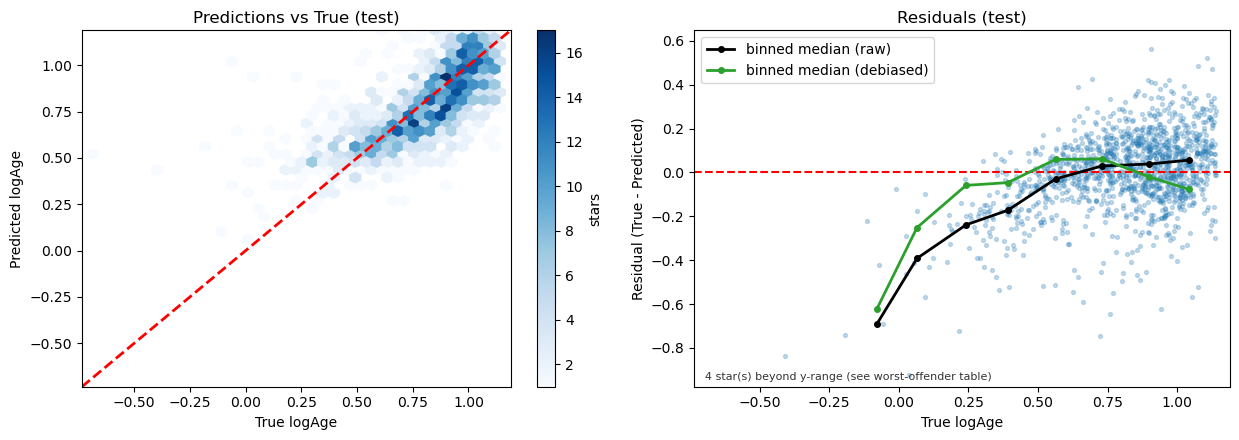

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
xlim = (float(y_test.min()) - 0.05, float(y_test.max()) + 0.05)

# Left: density (hexbin) instead of saturated scatter.
hb = axes[0].hexbin(y_test, summary['pred_median'], gridsize=40, cmap='Blues',
                    mincnt=1, extent=(*xlim, *xlim))
fig.colorbar(hb, ax=axes[0], label='stars')
axes[0].plot(xlim, xlim, 'r--', lw=2)
axes[0].set_xlim(xlim)
axes[0].set_ylim(xlim)
axes[0].set_xlabel('True logAge')
axes[0].set_ylabel('Predicted logAge')
axes[0].set_title('Predictions vs True (test)')

# Right: residuals with binned medians before/after the de-shrinkage. The raw
# curve shows the regression-to-the-mean trend; the debiased curve should sit
# near zero across the age range if the val-fit correction transfers.
axes[1].scatter(y_test, summary['residual'], alpha=0.25, s=8, color='tab:blue')
axes[1].axhline(0, color='r', ls='--')
bin_ids = np.digitize(y_test, edges[1:-1])
for col, color, label in [('residual', 'k', 'binned median (raw)'),
                          ('residual_debiased', 'tab:green', 'binned median (debiased)')]:
    centers, medians = [], []
    for b in np.unique(bin_ids):
        m = bin_ids == b
        if m.sum() >= 5:
            centers.append(np.median(y_test[m]))
            medians.append(np.median(summary[col].values[m]))
    axes[1].plot(centers, medians, 'o-', color=color, lw=2, ms=4, label=label)

# Robust y-range: a single catastrophic prediction should not squash the panel.
# Clipped stars are counted here and listed in the worst-offender table below.
ylo, yhi = np.percentile(summary['residual'], [0.5, 99.5])
pad = 0.2 * (yhi - ylo)
ylo, yhi = ylo - pad, yhi + pad
n_clip = int(((summary['residual'] < ylo) | (summary['residual'] > yhi)).sum())
axes[1].set_ylim(ylo, yhi)
if n_clip:
    axes[1].annotate(f'{n_clip} star(s) beyond y-range (see worst-offender table)',
                     xy=(0.02, 0.02), xycoords='axes fraction', fontsize=8, alpha=0.8)
axes[1].set_xlim(xlim)
axes[1].set_xlabel('True logAge')
axes[1].set_ylabel('Residual (True - Predicted)')
axes[1].set_title('Residuals (test)')
axes[1].legend()

plt.tight_layout()
plt.show()

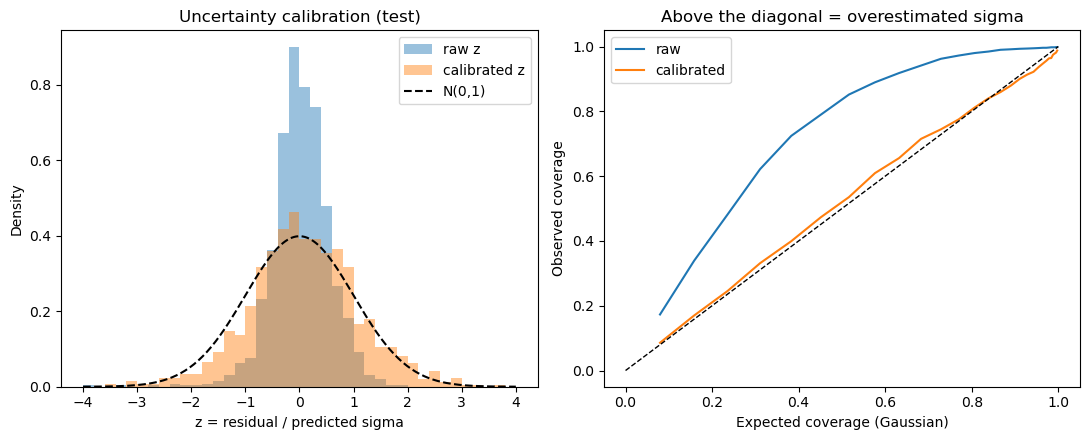

In [87]:
from math import erf

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# z-score histogram vs a unit normal
zgrid = np.linspace(-4, 4, 200)
axes[0].hist(summary['normalized_residual'], bins=40, range=(-4, 4), density=True,
             alpha=0.45, label='raw z')
axes[0].hist(summary['calibrated_z'], bins=40, range=(-4, 4), density=True,
             alpha=0.45, label='calibrated z')
axes[0].plot(zgrid, np.exp(-zgrid**2 / 2) / np.sqrt(2 * np.pi), 'k--', label='N(0,1)')
axes[0].set_xlabel('z = residual / predicted sigma')
axes[0].set_ylabel('Density')
axes[0].set_title('Uncertainty calibration (test)')
axes[0].legend()

# Coverage curve: fraction within k*sigma vs the Gaussian expectation
ks = np.linspace(0.1, 3.0, 30)
expected = np.array([erf(k / np.sqrt(2)) for k in ks])
for col, label in [('normalized_residual', 'raw'), ('calibrated_z', 'calibrated')]:
    observed = [(summary[col].abs() < k).mean() for k in ks]
    axes[1].plot(expected, observed, label=label)
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('Expected coverage (Gaussian)')
axes[1].set_ylabel('Observed coverage')
axes[1].set_title('Above the diagonal = overestimated sigma')
axes[1].legend()

plt.tight_layout()
plt.show()

### Calibration depth checks

Two questions the coverage numbers above cannot answer:

- **Is one scalar enough?** (left) The factor is fit globally on val; if the robust
  z width varies strongly with age, the tails need a per-age-bin factor instead.
- **Is σ informative?** (right) Coverage can be perfect with a constant σ. The
  per-star uncertainties only add value over a fixed error bar if larger predicted
  σ actually corresponds to larger errors — which is the BNN's whole justification
  over the point-estimate baselines in section 8.

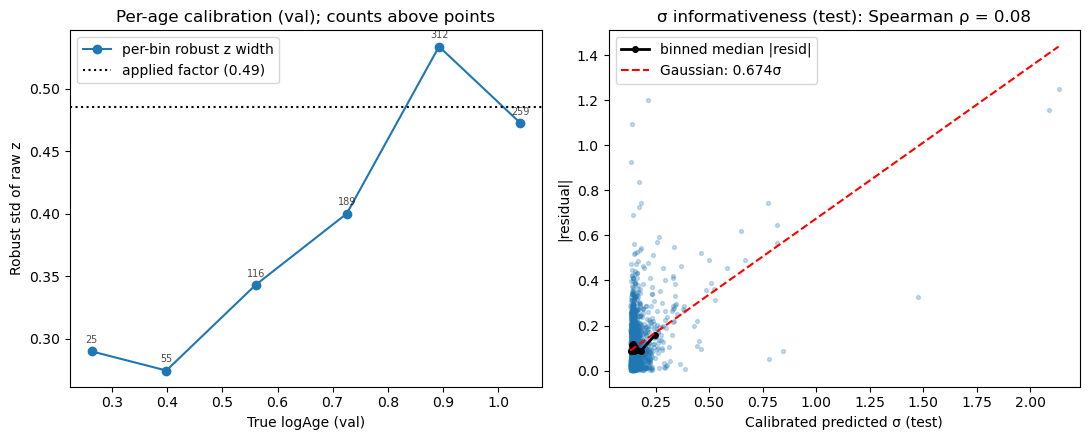

Spearman rank correlation (predicted σ vs |residual|, test): 0.078
~0 means σ carries no per-star information (only the average scale is right);
the binned median tracking the red 0.674σ line means σ ranks stars correctly.


In [88]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: is one scalar enough? Robust width of the RAW val z-scores per age bin,
# against the applied factor. Bins far off the dotted line are mis-calibrated in
# a way no global scalar can fix (expect the sparse young/old tails first).
zv = summary_val['normalized_residual'].values
bin_ids_val = np.digitize(y_val, edges[1:-1])
centers, widths, counts = [], [], []
for b in np.unique(bin_ids_val):
    m = bin_ids_val == b
    if m.sum() >= 10:
        zb = zv[m]
        centers.append(np.median(y_val[m]))
        widths.append(1.4826 * np.median(np.abs(zb - np.median(zb))))
        counts.append(int(m.sum()))
axes[0].plot(centers, widths, 'o-', color='tab:blue', label='per-bin robust z width')
for x, w_, n in zip(centers, widths, counts):
    axes[0].annotate(str(n), (x, w_), textcoords='offset points',
                     xytext=(0, 6), ha='center', fontsize=7, alpha=0.7)
axes[0].axhline(calib, color='k', ls=':', label=f'applied factor ({calib:.2f})')
axes[0].set_xlabel('True logAge (val)')
axes[0].set_ylabel('Robust std of raw z')
axes[0].set_title('Per-age calibration (val); counts above points')
axes[0].legend()

# Right: is sigma INFORMATIVE, not just calibrated on average? Coverage can hit
# 68/95 exactly with a constant sigma; the per-star uncertainties only add value
# if larger sigma actually predicts larger errors. For a Gaussian, the median
# |residual| at fixed sigma is 0.674*sigma.
sig = summary['calibrated_uncertainty'].values
absr = summary['residual'].abs().values
axes[1].scatter(sig, absr, alpha=0.25, s=8)
qs = np.quantile(sig, np.linspace(0, 1, 9))
mids, meds = [], []
for lo, hi in zip(qs[:-1], qs[1:]):
    m = (sig >= lo) & (sig <= hi)
    if m.sum() >= 5:
        mids.append(np.median(sig[m]))
        meds.append(np.median(absr[m]))
axes[1].plot(mids, meds, 'o-', color='k', lw=2, ms=4, label='binned median |resid|')
sgrid = np.linspace(sig.min(), sig.max(), 50)
axes[1].plot(sgrid, 0.6745 * sgrid, 'r--', label='Gaussian: 0.674σ')
rho = float(pd.Series(sig).rank().corr(pd.Series(absr).rank()))
axes[1].set_xlabel('Calibrated predicted σ (test)')
axes[1].set_ylabel('|residual|')
axes[1].set_title(f'σ informativeness (test): Spearman ρ = {rho:.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Spearman rank correlation (predicted σ vs |residual|, test): {rho:.3f}')
print('~0 means σ carries no per-star information (only the average scale is right);')
print('the binned median tracking the red 0.674σ line means σ ranks stars correctly.')

### Worst-offender inspection

The residual panel showed at least one catastrophic prediction (several dex off).
Those stars dominate any non-robust statistic, so name them: the worst test stars
by |calibrated z|, with their raw features, plus a flag for predictions that left
the training logAge range entirely. Cross-check the IDs against the young-α-rich
audit list in section 4 — overlap means bad labels, not a bad model.

In [89]:
# Ten worst test stars by |calibrated z|, with their raw features attached
# (test row order matches summary row order by construction). A cluster of
# extreme C_N / TEFF / low SNR here points at input-data problems; a lone
# wild prediction points at the network extrapolating.
worst_idx = summary['calibrated_z'].abs().nlargest(10).index
report = pd.concat(
    [summary.loc[worst_idx, ['APOGEE_ID', 'source', 'true_age', 'pred_median',
                             'calibrated_uncertainty', 'calibrated_z',
                             'pred_outside_train_range']],
     test.loc[worst_idx, ['TEFF', 'LOGG', 'FE_H', 'MG_FE', 'C_N', 'SNR']]],
    axis=1)
print(report.to_string(index=False,
                       float_format=lambda v: f'{v: .3f}'))
if n_out:
    print(f'\n{n_out} prediction(s) outside the training logAge range '
          f'[{train_lo:.2f}, {train_hi:.2f}] are flagged in '
          f"'pred_outside_train_range' (also saved in the summary CSV).")

         APOGEE_ID source  true_age  pred_median  calibrated_uncertainty  calibrated_z  pred_outside_train_range      TEFF   LOGG   FE_H  MG_FE    C_N      SNR
2M04214809-6118481   TESS    -0.078        1.016                   0.139        -7.884                     False  4561.044  2.847 -0.115  0.018 -0.075  457.919
2M18543598+4155476 Kepler     0.035        0.960                   0.136        -6.784                     False  4679.852  3.095 -0.116  0.070 -0.119  232.598
2M05142614-6452392   TESS    -0.685        0.517                   0.216        -5.570                     False  4672.238  2.855  0.085 -0.030 -0.458  602.560
2M19363769+3945006 Kepler    -0.409        0.429                   0.174        -4.825                     False  4734.403  2.701 -0.124 -0.123 -0.326  326.510
2M19333464+4622254 Kepler    -0.057        0.633                   0.146        -4.732                     False  4535.950  2.424 -0.232 -0.020 -0.315  558.643
2M08160345+1633593     K2     0.214     

In [90]:
# Per-mission breakdown of the single test evaluation: is the damage
# concentrated in the short-baseline missions? The model never sees the
# mission label -- this only groups the results.
rows = []
for src, g in list(summary.groupby('source')) + [('ALL', summary)]:
    z = g['calibrated_z']
    rows.append({
        'source': src, 'n': len(g),
        'corr': float(np.corrcoef(g['true_age'], g['pred_median'])[0, 1]),
        'rms': float(np.sqrt(np.mean(g['residual'] ** 2))),
        'median_bias': float(g['residual'].median()),
        'z_width': float(1.4826 * (z - z.median()).abs().median()),
        'median_logAgeErr': float(test.loc[g.index, 'logAgeErr'].median()),
    })
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f'{v: .3f}'))
print('\nIf K2/TESS carry the damage while Kepler stays tight, the fix is label')
print('quality (MAX_LOGAGE_ERR / selection purity), not model capacity.')

source    n   corr    rms  median_bias  z_width  median_logAgeErr
    K2  549  0.557  0.205        0.036    1.043             0.092
Kepler  679  0.743  0.169       -0.015    0.906             0.062
  TESS   67  0.584  0.245        0.061    0.727             0.075
   ALL 1295  0.673  0.189        0.009    0.947             0.074

If K2/TESS carry the damage while Kepler stays tight, the fix is label
quality (MAX_LOGAGE_ERR / selection purity), not model capacity.


## 8. Data-ceiling check

How close is the BNN to what these features can support? Two plain baselines
(closed-form ridge regression, inverse-distance-weighted kNN) run on the **identical**
split and features.

How to read the numbers:

- If a baseline beats the BNN on correlation/RMS, there is **headroom** — the features
  hold signal the BNN is not extracting, so training/architecture (not the data) is
  the limit.
- Slope < 1 is regression toward the mean. The inverse-frequency age weighting
  deliberately trades some RMS for a slope closer to 1, so the BNN can legitimately
  show worse RMS but a much better slope than an unweighted baseline. Decide which
  matters for the science before "fixing" either.

In [91]:
from sklearn.ensemble import HistGradientBoostingRegressor


def _metrics(y, p):
    return (float(np.corrcoef(y, p)[0, 1]),
            float(np.sqrt(np.mean((y - p) ** 2))),
            float(np.polyfit(y, p, 1)[0]))


# Ridge regression (closed form, small penalty; the intercept is not penalized)
A = np.hstack([X_train, np.ones((len(X_train), 1))])
At = np.hstack([X_test, np.ones((len(X_test), 1))])
penalty = 1e-2 * np.eye(A.shape[1])
penalty[-1, -1] = 0.0
coef = np.linalg.solve(A.T @ A + penalty, A.T @ y_train)
ridge_pred = At @ coef

# Inverse-distance-weighted kNN
d = np.sqrt(((X_test[:, None, :] - X_train[None, :, :]) ** 2).sum(-1))
nn = np.argsort(d, axis=1)[:, :10]
dd = np.take_along_axis(d, nn, axis=1)
wts = 1.0 / (dd + 1e-6)
wts /= wts.sum(axis=1, keepdims=True)
knn_pred = (y_train[nn] * wts).sum(axis=1)

# Gradient-boosted trees: close to the practical ceiling for a handful of
# tabular features, so this is the strongest "is there headroom?" referee.
gbt = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.05,
                                    early_stopping=True, random_state=SEED)
gbt.fit(X_train, y_train)
gbt_pred = gbt.predict(X_test)

results = {name: _metrics(y_test, p)
           for name, p in [('ridge', ridge_pred),
                           ('kNN k=10', knn_pred),
                           ('GBT', gbt_pred),
                           ('BNN', summary['pred_median'].values),
                           ('BNN debiased', summary['pred_debiased'].values)]}
print(f"{'model':12s} {'corr':>6s} {'RMS':>7s} {'slope':>7s}   (test, n={len(y_test)})")
for name, (c, r, s) in results.items():
    print(f'{name:12s} {c:6.3f} {r:7.3f} {s:7.3f}')
print(f"{'mean-only':12s} {'--':>6s} {y_test.std():7.3f} {0.0:7.3f}   (predict-the-mean floor)")

# Verdict driven by the numbers, not asserted. The debiased row shares the BNN's
# corr (an affine map cannot change rank order) but shows the slope fix; RMS can
# go up in the dense bulk -- that is the price of unbiased tails.
BASELINES = ('ridge', 'kNN k=10', 'GBT')
bnn_c, bnn_r, bnn_s = results['BNN']
base_c = max(results[b][0] for b in BASELINES)
base_r = min(results[b][1] for b in BASELINES)
print()
if bnn_c >= base_c - 0.01 and bnn_r <= base_r + 0.01:
    print('BNN matches or beats the baselines => it is extracting what the features')
    print('hold; further gains need better labels or features, not more training.')
else:
    print(f'A baseline beats the BNN on point accuracy (corr {base_c:.3f} vs {bnn_c:.3f}, '
          f'RMS {base_r:.3f} vs {bnn_r:.3f}) => headroom remains.')
    print(f'Note the BNN slope ({bnn_s:.3f}) vs the baselines: the age weighting')
    print('deliberately trades RMS for less regression to the mean.')

model          corr     RMS   slope   (test, n=1295)
ridge         0.720   0.165   0.541
kNN k=10      0.742   0.160   0.539
GBT           0.763   0.154   0.587
BNN           0.673   0.189   0.653
BNN debiased  0.673   0.266   1.014
mean-only        --   0.237   0.000   (predict-the-mean floor)

A baseline beats the BNN on point accuracy (corr 0.763 vs 0.673, RMS 0.154 vs 0.189) => headroom remains.
Note the BNN slope (0.653) vs the baselines: the age weighting
deliberately trades RMS for less regression to the mean.


In [92]:
import joblib

# Everything needed to reproduce predictions, in one bundle next to the param
# store. NOTE: the learned posterior lives in the Pyro param store
# (targeted_bnn_params.pth, saved in section 6) -- model.state_dict() alone
# cannot restore a Pyro BNN, so no state_dict is saved.
bundle = {
    'features': FEATURES,
    'stats': stats,                 # per-feature {"mean","std"} from TRAIN only
    'y_mean': y_mean,
    'y_std': y_std,
    'model_kwargs': MODEL_KWARGS,   # re-instantiate the identical architecture
    'age_bin_edges': edges,
    'weight_clip': WEIGHT_CLIP,
    'seed': SEED,
    'calibration_factor': calib,    # robust (1.4826*MAD) val z width; multiply predicted sigmas by this
    'calibration_factor_std': calib_std,  # plain val z std, for reference/diagnostics
    # De-shrinkage from the sigma-clipped INVERSE calibration fit on val
    # (pred ~ c*true + d, inverted). To use debiased point predictions at
    # inference: pred' = a*pred + b, sigma' = raw_sigma * sigma_factor.
    'affine_debias': {'a': float(a_cal), 'b': float(b_cal),
                      'sigma_factor': calib_db},
    # Predictions outside this logAge range are extrapolation failures; flag them.
    'train_label_range': [train_lo, train_hi],
    'param_store_file': 'targeted_bnn_params.pth',
}
joblib.dump(bundle, OUTPUT_DIR / 'bnn_inference_bundle_rgb.pkl')
print(f"Saved {OUTPUT_DIR / 'bnn_inference_bundle_rgb.pkl'}")

# The reload recipe is not just documented -- the next cell executes it and
# asserts the reloaded model reproduces the in-memory predictions.

Saved BNN_targeted_output_RGB/bnn_inference_bundle_rgb.pkl
